In [70]:
import tensorflow as tf

# Get the GPU device name.
device_name = tf.test.gpu_device_name()

# The device name should look like the following:
if device_name == '/device:GPU:0':
    print('Found GPU at: {}'.format(device_name))
else:
    raise SystemError('GPU device not found')

Found GPU at: /device:GPU:0


I0000 00:00:1768236749.444862   12405 gpu_device.cc:2019] Created device /device:GPU:0 with 13294 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:c8:00.0, compute capability: 8.6


In [71]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():    

    # Tell PyTorch to use the GPU.    
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA A16


In [72]:
## !pip install transformers=='2.8.0'

In [73]:
##pip install emoji

In [74]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [75]:
import pandas as pd
import re
import emoji

# Load the dataset into a pandas dataframe.
train_df = pd.read_csv('eds-ai-hs25/data/train.csv',encoding='UTF-8')

# Report the number of sentences.
print('Number of training sentences: {:,}\n'.format(train_df.shape[0]))

# Display 10 random rows from the data.
train_df.sample(10)

Number of training sentences: 7,613



,id,keyword,location,text,target
7334,10499,wildfire,"Ashland, Oregon",Be ember aware! http://t.co/LZmL1xB2nH,1
6683,9576,thunder,"New York, USA",Waldo Thunder 12U Cooperstown Dreams Park 2015...,0
35,53,ablaze,"London, UK",On plus side LOOK AT THE SKY LAST NIGHT IT WAS...,0
7372,10554,windstorm,"Austin, Texas",Windstorm board OKs rate hike before change ht...,0
6556,9380,survived,Bulgaria,Cute &amp; all livin' the life then you zoom i...,0
3420,4893,explode,"Dallas, TX",@deniseromano @megynkelly @GOP That's one way ...,0
5500,7849,quarantined,"Cumming, GA",Reddit's new content policy goes into effect m...,0
265,383,annihilation,Connecticut,@SonofBaldwin and he's the current Nova in the...,0
5985,8546,screams,NaN,When you on the phone and @Worstoverdose screa...,0
4925,7015,mayhem,107-18 79TH STREET,#NoSurrender Results: Full Metal Mayhem World ...,0


In [76]:
# #HappyEmoticons
emoticons_happy = set([
     ':-)', ':)', ';)', ':o)', ':]', ':3', ':c)', ':>', '=]', '8)', '=)', ':}',
     ':^)', ':-D', ':D', '8-D', '8D', 'x-D', 'xD', 'X-D', 'XD', '=-D', '=D',
     '=-3', '=3', ':-))', ":'-)", ":')", ':*', ':^*', '>:P', ':-P', ':P', 'X-P',
     'x-p', 'xp', 'XP', ':-p', ':p', '=p', ':-b', ':b', '>:)', '>;)', '>:-)',
     '<3'
     ])

# # Sad Emoticons
emoticons_sad = set([
     ':L', ':-/', '>:/', ':S', '>:[', ':@', ':-(', ':[', ':-||', '=L', ':<',
     ':-[', ':-<', '=\\', '=/', '>:(', ':(', '>.<', ":'-(", ":'(", ':\\', ':-c',
     ':c', ':{', '>:\\', ';('
     ])

# #combine sad and happy emoticons
emoticons = emoticons_happy.union(emoticons_sad)


#Emoji patterns
emoji_pattern = re.compile("["
         u"\U0001F600-\U0001F64F"  # emoticons
         u"\U0001F300-\U0001F5FF"  # symbols & pictographs
         u"\U0001F680-\U0001F6FF"  # transport & map symbols
         u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
         u"\U00002702-\U000027B0"
         u"\U000024C2-\U0001F251"
         "]+", flags=re.UNICODE)

In [77]:
from nltk.tokenize import WordPunctTokenizer
import re
import emoji
from bs4 import BeautifulSoup
import itertools

tok = WordPunctTokenizer()
pat1 = r'@[A-Za-z0-9]+'
pat2 = r'https?://[A-Za-z0-9./]+'

def tweet_cleaner(text): # ref: https://towardsdatascience.com/another-twitter-sentiment-analysis-bb5b01ebad90
    # removing UTF-8 BOM (Byte Order Mark)
    try:
        text1 = text.decode("utf-8-sig").replace(u"\ufffd", "?") # The UTF-8 BOM is a sequence of bytes (EF BB BF) that allows the reader to identify a file as being encoded in UTF-8
    except:
        text1 = text
    
    
    #replace consecutive non-ASCII characters with a space
    text1 = re.sub(r'[^\x00-\x7F]+',' ', text1)
    
    #remove emojis from tweet
    text2 = emoji_pattern.sub(r'', text1)
    
    # Remove emoticons
    # text3 = [word for word in text2.split() if word not in emoticons]
    # text3 = " ".join(text3)
    
    # contradictions and special characters 
    # text4 = spl_ch_contra(text3)
    
    # HTML encoding
    soup = BeautifulSoup(text2, 'lxml') #HTML encoding has not been converted to text, and ended up in text field as ‘&amp’,’&quot’,etc.
    text5 = soup.get_text()
    
    # removing @ mentions
    text6 = re.sub(pat1, '', text5)
    
    # Removing URLs
    text7 = re.sub(pat2, '', text6)
    
    # Removing punctuations
    # text8 = re.sub("[\.\,\!\?\:\;\-\=\(\)\[\]\"\'\%\*\#\@]", " ", text7)
    
    # Fix misspelled words
    text9 = ''.join(''.join(s)[:2] for _, s in itertools.groupby(text7))# checking that each character should occur not more than 2 times in every word

    # Tokenizing ,change cases & join together to remove unneccessary white spaces
    text9_list = tok.tokenize(text9.lower())
    text10 = (" ".join(text9_list)).strip()
    
    return text10

In [78]:
import re
import html
import itertools
import pandas as pd

# Deine Patterns (falls sie schon existieren, ist das ok)
pat1 = r'@[A-Za-z0-9_]+'          # mentions
pat2 = r'https?://[A-Za-z0-9./]+' # urls

def tweet_cleaner(text):
    # 1) NaNs abfangen
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text)

    # 2) UTF-8 BOM / komische Replacement-Char entfernen (wie bei dir)
    text = text.replace("\ufeff", "").replace("\ufffd", "?")

    # 3) Non-ASCII raus (wie bei dir)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # 4) Emojis raus (emoji_pattern hast du schon vorher definiert)
    text = emoji_pattern.sub('', text)

    # 5) HTML entities decoden (&amp; -> &, &quot; -> ")
    text = html.unescape(text)

    # 6) HTML Tags entfernen (<br>, <a ...>, etc.)
    text = re.sub(r'<[^>]+>', ' ', text)

    # 7) @mentions entfernen
    text = re.sub(pat1, ' ', text)

    # 8) URLs entfernen
    text = re.sub(pat2, ' ', text)

    # 9) Mehrfachzeichen reduzieren (deine groupby-Idee)
    text = "".join("".join(s)[:2] for _, s in itertools.groupby(text))

    # 10) lower + simple token cleanup (ähnlich deinem tok.tokenize)
    text = re.sub(r'\s+', ' ', text).strip().lower()

    return text


In [79]:
train_df["text_cleaned"] = train_df["text"].apply(tweet_cleaner)


In [80]:
# checking out few samples
train_df.sample(10)

,id,keyword,location,text,target,text_cleaned
1314,1898,burning,NaN,If you're bored with life if you don't get up ...,0,if you're bored with life if you don't get up ...
4365,6200,hijacker,Halifax,Remove the http://t.co/l4wJHz4AJ6 and Linkury ...,0,remove the and linkury browser hijacker
1615,2333,collapse,In the clouds...,@BehindAShield @Wars_Goddess Sweet Lord. (I c...,0,sweet lord. (i collapse as my knees buckle)
5960,8511,screaming,Justin and Ariana follow,MY FAVS I'M SCREAMING SO FUCKING LOUD http://t...,0,my favs i'm screaming so fucking loud
1330,1921,burning%20buildings,"Sacramento, CA",Killing Black Babies at Planned Parenthood whe...,1,killing black babies at planned parenthood whe...
843,1223,blizzard,NaN,Market News: Activision Blizzard Cognizant Tec...,0,market news: activision blizzard cognizant tec...
1565,2260,cliff%20fall,At Da Laundry Mat Wit Nivea,2Leezy its like you're about to fall down a cl...,1,2leezy its like you're about to fall down a cl...
6046,8642,sinkhole,Unknown,Sinkhole Selfies: You Wont Believe What's In T...,0,sinkhole selfies: you wont believe what's in t...
2858,4107,drought,Nigeria,w--=-=-=-[ NEMA warns Nigerians to prepare for...,1,w--=-=-=-[ nema warns nigerians to prepare for...
4224,5999,hazardous,NaN,From recycling to only using non-hazardous che...,1,from recycling to only using non-hazardous che...


In [81]:
# Get the lists of sentences and their labels.
sentences = train_df.text_cleaned.values
labels = train_df.target.values

## 3 Tokenization 

In [82]:
from transformers import BertTokenizer

# Load the BERT tokenizer.
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

Loading BERT tokenizer...


In [83]:
# Print the original sentence.
print(' Original: ', sentences[0])

# Print the tweet split into tokens.
print('Tokenized: ', tokenizer.tokenize(sentences[0]))

# Print the tweet mapped to token ids.
print('Token IDs: ', tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sentences[0])))

 Original:  our deeds are the reason of this #earthquake may allah forgive us all
Tokenized:  ['our', 'deeds', 'are', 'the', 'reason', 'of', 'this', '#', 'earthquake', 'may', 'allah', 'forgive', 'us', 'all']
Token IDs:  [2256, 15616, 2024, 1996, 3114, 1997, 2023, 1001, 8372, 2089, 16455, 9641, 2149, 2035]


In [84]:
max_len = 0

# For every sentence...
for sent in sentences:

    # Tokenize the text and add `[CLS]` and `[SEP]` tokens.
    input_ids = tokenizer.encode(sent, add_special_tokens=True)

    # Update the maximum sentence length.
    max_len = max(max_len, len(input_ids))

print('Max sentence length: ', max_len)

Max sentence length:  67


In [85]:
input_ids = []
attention_masks = []

for sent in sentences:
    encoded_dict = tokenizer.encode_plus(
        sent,
        add_special_tokens=True,
        max_length=75,
        padding='max_length',      # statt pad_to_max_length=True
        truncation=True,           # wichtig! sonst gibt’s Längenchaos
        return_attention_mask=True,
        return_tensors='pt',
    )

    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

print('Original: ', sentences[1])
print('Token IDs:', input_ids[1])


Original:  forest fire near la ronge sask. canada
Token IDs: tensor([  101,  3224,  2543,  2379,  2474,  6902,  3351, 21871,  2243,  1012,
         2710,   102,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0])


In [86]:
input_ids = []
attention_masks = []

for sent in sentences:
    encoded_dict = tokenizer.encode_plus(
        sent,
        add_special_tokens=True,
        max_length=75,
        padding='max_length',      # statt pad_to_max_length=True
        truncation=True,           # wichtig! sonst gibt’s Längenchaos
        return_attention_mask=True,
        return_tensors='pt',
    )

    input_ids.append(encoded_dict['input_ids'])
    attention_masks.append(encoded_dict['attention_mask'])

input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(labels)

print('Original: ', sentences[1])
print('Token IDs:', input_ids[1])


Original:  forest fire near la ronge sask. canada
Token IDs: tensor([  101,  3224,  2543,  2379,  2474,  6902,  3351, 21871,  2243,  1012,
         2710,   102,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0])


/tmp/ipykernel_12405/1298514162.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels)


In [87]:
import numpy as np

def compute_binary_metrics_from_logits(all_logits, all_labels):
    """
    all_logits: np.array shape (N, 2)
    all_labels: np.array shape (N,)
    """
    preds = np.argmax(all_logits, axis=1)

    tp = np.sum((preds == 1) & (all_labels == 1))
    tn = np.sum((preds == 0) & (all_labels == 0))
    fp = np.sum((preds == 1) & (all_labels == 0))
    fn = np.sum((preds == 0) & (all_labels == 1))

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)

    conf_mat = np.array([[tn, fp],
                         [fn, tp]])

    return accuracy, precision, recall, f1, conf_mat


## 3.4 Training & Validation Split

In [88]:
from torch.utils.data import TensorDataset, random_split

# Combine the training inputs into a TensorDataset.
dataset = TensorDataset(input_ids, attention_masks, labels)

# Create a 90-10 train-validation split.

# Calculate the number of samples to include in each set.
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

# Divide the dataset by randomly selecting samples.
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# print('{:>5,} training samples'.format(train_size))
# print('{:>5,} validation samples'.format(val_size))

# Checking whether the distribution of target is consitent across both the sets
label_temp_list = []
for a,b,c in train_dataset:
  label_temp_list.append(c)

print('{:>5,} training samples'.format(train_size))
print('{:>5,} training samples with real disater tweets'.format(sum(label_temp_list)))


label_temp_list = []
for a,b,c in val_dataset:
  label_temp_list.append(c)

print('{:>5,} validation samples'.format(val_size))
print('{:>5,} validation samples with real disater tweets'.format(sum(label_temp_list)))

6,851 training samples
2,933 training samples with real disater tweets
  762 validation samples
  338 validation samples with real disater tweets


In [89]:
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler

# The DataLoader needs to know our batch size for training, so we specify it 
# here. For fine-tuning BERT on a specific task, the authors recommend a batch 
# size of 16 or 32.
batch_size = 32

# Create the DataLoaders for our training and validation sets.
# We'll take training samples in random order. 
train_dataloader = DataLoader(
            train_dataset,  # The training samples.
            sampler = RandomSampler(train_dataset), # Select batches randomly
            batch_size = batch_size # Trains with this batch size.
        )

# For validation the order doesn't matter, so we'll just read them sequentially.
validation_dataloader = DataLoader(
            val_dataset, # The validation samples.
            sampler = SequentialSampler(val_dataset), # Pull out batches sequentially.
            batch_size = batch_size # Evaluate with this batch size.
        )

## 4 Train Classification Model

In [90]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False,
)

model = model.cuda()  # oder model.to(device)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [91]:
# Get all of the model's parameters as a list of tuples.
params = list(model.named_parameters())

print('The BERT model has {:} different named parameters.\n'.format(len(params)))

print('==== Embedding Layer ====\n')

for p in params[0:5]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== First Transformer ====\n')

for p in params[5:21]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

print('\n==== Output Layer ====\n')

for p in params[-4:]:
    print("{:<55} {:>12}".format(p[0], str(tuple(p[1].size()))))

The BERT model has 201 different named parameters.

==== Embedding Layer ====

bert.embeddings.word_embeddings.weight                  (30522, 768)
bert.embeddings.position_embeddings.weight                (512, 768)
bert.embeddings.token_type_embeddings.weight                (2, 768)
bert.embeddings.LayerNorm.weight                              (768,)
bert.embeddings.LayerNorm.bias                                (768,)

==== First Transformer ====

bert.encoder.layer.0.attention.self.query.weight          (768, 768)
bert.encoder.layer.0.attention.self.query.bias                (768,)
bert.encoder.layer.0.attention.self.key.weight            (768, 768)
bert.encoder.layer.0.attention.self.key.bias                  (768,)
bert.encoder.layer.0.attention.self.value.weight          (768, 768)
bert.encoder.layer.0.attention.self.value.bias                (768,)
bert.encoder.layer.0.attention.output.dense.weight        (768, 768)
bert.encoder.layer.0.attention.output.dense.bias              (

In [92]:
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8, weight_decay=0.01)



In [93]:
from transformers import get_linear_schedule_with_warmup

# Number of training epochs. The BERT authors recommend between 2 and 4. 
# We chose to run for 2,I have already seen that the model starts overfitting beyound 2 epochs
epochs = 2

# Total number of training steps is [number of batches] x [number of epochs]. 
# (Note that this is not the same as the number of training samples).
total_steps = len(train_dataloader) * epochs

# Create the learning rate scheduler.
scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps = 0, # Default value in run_glue.py
                                            num_training_steps = total_steps)

In [94]:
##Training loop

import numpy as np

# Function to calculate the accuracy of our predictions vs labels
def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

In [95]:
import time
import datetime

def format_time(elapsed):
    '''
    Takes a time in seconds and returns a string hh:mm:ss
    '''
    # Round to the nearest second.
    elapsed_rounded = int(round((elapsed)))
    
    # Format as hh:mm:ss
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [105]:
def compute_binary_metrics_from_logits(all_logits, all_labels):
    preds = np.argmax(all_logits, axis=1)

    tp = np.sum((preds == 1) & (all_labels == 1))
    tn = np.sum((preds == 0) & (all_labels == 0))
    fp = np.sum((preds == 1) & (all_labels == 0))
    fn = np.sum((preds == 0) & (all_labels == 1))

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-12)

    conf_mat = np.array([[tn, fp],
                         [fn, tp]])

    return accuracy, precision, recall, f1, conf_mat


In [106]:
import time
import random
import numpy as np
import torch

# Reproducibility
seed_val = 66
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

training_stats = []
total_t0 = time.time()

for epoch_i in range(epochs):

    print("")
    print(f"======== Epoch {epoch_i + 1} / {epochs} ========")
    print("Training...")

    t0 = time.time()
    total_train_loss = 0.0

    model.train()

    for step, batch in enumerate(train_dataloader):

        if step % 40 == 0 and step != 0:
            elapsed = format_time(time.time() - t0)
            print(f"  Batch {step:>5,}  of  {len(train_dataloader):>5,}.    Elapsed: {elapsed}.")

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        optimizer.zero_grad()

        # ✅ NEW: outputs object
        outputs = model(
            input_ids=b_input_ids,
            attention_mask=b_input_mask,
            labels=b_labels
        )

        loss = outputs.loss          # Tensor
        logits = outputs.logits      # Tensor [batch, num_labels]

        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)

    print("")
    print(f"  Average training loss: {avg_train_loss:.4f}")
    print(f"  Training epoch took: {training_time}")

    # =======================
    # Validation
    # =======================
    print("")
    print("Running Validation...")

    t0 = time.time()
    model.eval()

    total_eval_loss = 0.0

    all_val_logits = []
    all_val_labels = []

    for batch in validation_dataloader:

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(
                input_ids=b_input_ids,
                attention_mask=b_input_mask,
                labels=b_labels
            )

        loss = outputs.loss
        logits = outputs.logits
    
        total_eval_loss += loss.item()

        all_val_logits.append(logits.detach().cpu().numpy())
        all_val_labels.append(b_labels.detach().cpu().numpy())

    # ---- compute metrics over ALL validation samples ----
    all_val_logits = np.concatenate(all_val_logits, axis=0)
    all_val_labels = np.concatenate(all_val_labels, axis=0)

    val_acc, val_precision, val_recall, val_f1, val_cm = compute_binary_metrics_from_logits(
        all_val_logits, all_val_labels
    )

    avg_val_loss = total_eval_loss / len(validation_dataloader)
    validation_time = format_time(time.time() - t0)

    print(f"  Accuracy:  {val_acc:.4f}")
    print(f"  Precision: {val_precision:.4f}")
    print(f"  Recall:    {val_recall:.4f}")
    print(f"  F1:        {val_f1:.4f}")
    print(f"  Val Loss:  {avg_val_loss:.4f}")
    print("  Confusion Matrix:\n", val_cm)



    training_stats.append({
        "epoch": epoch_i + 1,
        "Training Loss": avg_train_loss,
        "Valid. Loss": avg_val_loss,
        "Valid. Accur.": val_acc,
        "Valid. Prec.": val_precision,
        "Valid. Recall": val_recall,
        "Valid. F1": val_f1,
        "Training Time": training_time,
        "Validation Time": validation_time
    })

print("")
print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time() - total_t0)))



======== Epoch 1 / 2 ========
Training...
  Batch    40  of    215.    Elapsed: 0:00:26.
  Batch    80  of    215.    Elapsed: 0:00:52.
  Batch   120  of    215.    Elapsed: 0:01:18.
  Batch   160  of    215.    Elapsed: 0:01:44.
  Batch   200  of    215.    Elapsed: 0:02:10.

  Average training loss: 0.1871
  Training epoch took: 0:02:20

Running Validation...
  Accuracy:  0.8294
  Precision: 0.8059
  Recall:    0.8107
  F1:        0.8083
  Val Loss:  0.4244
  Confusion Matrix:
 [[358  66]
 [ 64 274]]

======== Epoch 2 / 2 ========
Training...
  Batch    40  of    215.    Elapsed: 0:00:26.
  Batch    80  of    215.    Elapsed: 0:00:52.
  Batch   120  of    215.    Elapsed: 0:01:18.
  Batch   160  of    215.    Elapsed: 0:01:44.
  Batch   200  of    215.    Elapsed: 0:02:10.

  Average training loss: 0.2925
  Training epoch took: 0:02:20

Running Validation...
  Accuracy:  0.8294
  Precision: 0.8059
  Recall:    0.8107
  F1:        0.8083
  Val Loss:  0.4244
  Confusion Matrix:
 [[358

In [107]:
import pandas as pd

# Display floats with two decimal places (pandas >= 2.x)
pd.set_option("display.precision", 2)

# Create a DataFrame from our training statistics.
df_stats = pd.DataFrame(training_stats)

# Use the 'epoch' as the row index.
df_stats = df_stats.set_index("epoch")

df_stats


,Training Loss,Valid. Loss,Valid. Accur.,Valid. Prec.,Valid. Recall,Valid. F1,Training Time,Validation Time
epoch,,,,,,,,
1,0.19,0.42,0.83,0.81,0.81,0.81,0:02:20,0:00:05
2,0.29,0.42,0.83,0.81,0.81,0.81,0:02:20,0:00:05


In [108]:
import numpy as np

def flat_f1_score(logits, labels):
    """
    logits: numpy array shape (batch_size, 2)
    labels: numpy array shape (batch_size,)
    """
    preds = np.argmax(logits, axis=1)

    tp = np.sum((preds == 1) & (labels == 1))
    fp = np.sum((preds == 1) & (labels == 0))
    fn = np.sum((preds == 0) & (labels == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return f1


In [109]:
all_val_logits = []
all_val_labels = []


In [110]:
all_val_logits.append(logits)
all_val_labels.append(label_ids)


In [111]:
all_val_logits = np.concatenate(all_val_logits, axis=0)
all_val_labels = np.concatenate(all_val_labels, axis=0)

avg_val_f1 = flat_f1_score(all_val_logits, all_val_labels)


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [112]:
print(f"  F1: {avg_val_f1:.4f}")


  F1: 0.7857


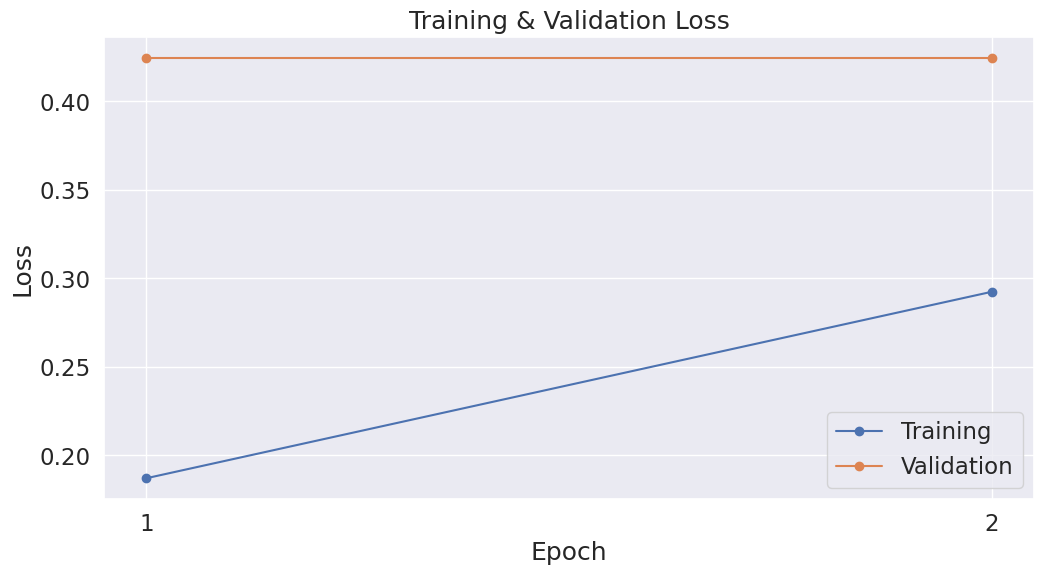

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Jupyter only (optional):
%matplotlib inline

# Styling
sns.set(style="darkgrid", font_scale=1.5)

# Plot size
plt.figure(figsize=(12, 6))

# Plot learning curves
plt.plot(df_stats["Training Loss"], marker="o", label="Training")
plt.plot(df_stats["Valid. Loss"], marker="o", label="Validation")

# Labels
plt.title("Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Epoch ticks (automatisch passend)
plt.xticks(df_stats.index)

plt.show()
